### Load packages

In [ ]:
import pandas as pd
import os
import numpy as np

import matplotlib.pyplot as plt


### Set file information

In [81]:
# Unified VCT file info

vct_directory = r"..\data\unified_csvs"
vct_file = "vct_unified"

vct_path = os.path.join(vct_directory, vct_file + ".csv")
print(vct_path)

..\data\unified_csvs\vct_unified.csv


In [82]:
# Output file info

output_directory = r"..\data\unified_csvs"
output_file = "vct_unified_prepped"

output_path = os.path.join(output_directory, output_file + ".csv")
print(output_path)

..\data\unified_csvs\vct_unified_prepped.csv


### Read in data

In [83]:
# Read in Vermont Cyanobacteria Tracker unified csv file

vct_raw_df = pd.read_csv(vct_path)

vct_raw_df.head()

,REPORTDATE,REPORTTIME,WATERBODY,REGION,MUNICIPALITY,SITE,STATION,BLOOMINTENSITY,REPORTFREQUENCY,AFFILIATION,WEBSTATUS,DETAILS,WATERTEMP,WATERSURFACE,CYANOTAXA,OTHERTAXA,MICROCYSTIN,ANATOXIN,LATITUDE,LONGITUDE
0,08/01/2022,10:45 AM,Lake Champlain,Champlain - South Lake,Benson,2.0,LTM 02,1b - No Cyanobacteria Observed - brown or turb...,Routine - Biweekly,VT DEC,Generally Safe,NaN,76.0,Rolling,NaN,NaN,NaN,NaN,43.71400891,-73.383001
1,08/22/2022,10:00 AM,Lake Champlain,Champlain - South Lake,Benson,2.0,LTM 02,1b - No Cyanobacteria Observed - brown or turb...,Routine - Biweekly,VT DEC,Generally Safe,NaN,77.0,Calm,NaN,NaN,NaN,NaN,43.71400891,-73.383001
2,10/05/2022,10:30 AM,Lake Champlain,Champlain - South Lake,Benson,2.0,LTM 02,1b - No Cyanobacteria Observed - brown or turb...,Routine - Biweekly,VT DEC,Generally Safe,NaN,57.0,Calm,NaN,NaN,NaN,NaN,43.71400891,-73.383001
3,10/21/2022,10:30 AM,Lake Champlain,Champlain - South Lake,Benson,2.0,LTM 02,1b - No Cyanobacteria Observed - brown or turb...,Routine - Biweekly,VT DEC,Generally Safe,NaN,52.0,Rolling,NaN,NaN,NaN,NaN,43.71400891,-73.383001
4,06/23/2022,2:35 PM,Lake Champlain,Champlain - Main Lake South,Panton,3.0,Arnold Bay,1a - No Cyanobacteria Observed - clear water,Routine - Weekly,LCC Volunteer,Generally Safe,NaN,NaN,Rolling,NaN,NaN,NaN,NaN,44.14952128,-73.367368


### Format data & columns

In [84]:
# Make safe copy of original data

vct_cleancols_df = vct_raw_df.copy()

In [85]:
vct_cleancols_df.columns

Index(['REPORTDATE', 'REPORTTIME', 'WATERBODY', 'REGION', 'MUNICIPALITY',
       'SITE', 'STATION', 'BLOOMINTENSITY', 'REPORTFREQUENCY', 'AFFILIATION',
       'WEBSTATUS', 'DETAILS', 'WATERTEMP', 'WATERSURFACE', 'CYANOTAXA',
       'OTHERTAXA', 'MICROCYSTIN', 'ANATOXIN', 'LATITUDE', 'LONGITUDE'],
      dtype='object')

In [86]:
# Turn all columns into lower case and then give some of them nicer names

vct_cleancols_df.columns = vct_cleancols_df.columns.str.lower()

col_map = {
    "reportdate": "report_date",
    "bloomintensity": "bloom_intensity",
    "watertemp": "water_temp",
    "watersurface": "water_surface"
}

vct_cleancols_df.rename(columns=col_map, inplace=True)

In [113]:
# Force dates to MM/DD/YYYY format

vct_cleancols_df["report_date"] = (
    pd.to_datetime(vct_cleancols_df["report_date"], errors="coerce")
      .dt.strftime("%m/%d/%Y")
)

vct_cleancols_df["report_date"] = pd.to_datetime(
    vct_cleancols_df["report_date"],
    errors="coerce"
)

print(vct_cleancols_df["report_date"].min())
print(vct_cleancols_df["report_date"].max())

2012-06-21 00:00:00
2022-11-26 00:00:00


In [88]:
# Force integers columns to integers

vct_cleancols_df["site"] = (
    pd.to_numeric(vct_cleancols_df["site"], errors="coerce")
        .astype("Int64")
)

In [89]:
# QC BLOOMINTENSITY

mask = ~vct_cleancols_df["bloom_intensity"].str.startswith(
    tuple(["1", "2", "3"]),
    na=False
)
bloom_intensity_df = vct_cleancols_df[mask]
bloom_intensity_df["bloom_intensity"].value_counts()

bloom_intensity
Tiered Alert - Quantitative    176
Quantitative                    62
Qualitative                     16
Alert 1                          7
Alert 2                          3
Vigilance                        2
Tiered Alert - Vigilance         2
Tiered Alert - Alert 1           2
Water Sample Only                1
Name: count, dtype: int64

In [90]:
# Filter to only keep rows where BLOOMINTENSITY start with 1, 2, or 3
# (i.e. none of the above cell's values, and no NaNs)

print("Rows before filtering:", len(vct_cleancols_df))

vct_intensity_df = vct_cleancols_df[
    vct_cleancols_df["bloom_intensity"].str.startswith(("1", "2", "3"), na=False)
]

print("Rows after filtering:", len(vct_intensity_df))

# print(vct_intensity_df["bloom_intensity"].unique())

Rows before filtering: 20601
Rows after filtering: 19604


In [91]:
# Create new column as first two characters of bloom_intensity for our targets

vct_bloom_df = vct_intensity_df.copy()

vct_bloom_df["target_bloom_intensity"] = (vct_bloom_df["bloom_intensity"].astype(str).str[:2]
                                          .str.strip()
                                          .where(vct_bloom_df["bloom_intensity"].notna())
)

first_digit = (
    vct_bloom_df["bloom_intensity"]
        .astype(str)
        .str.strip()
        .str[0]
)

vct_bloom_df["target_bloom"] = (
    first_digit.isin(["2", "3"])
)

# Set target_bloom_tf to 0/1 instead of T/F
vct_bloom_df["target_bloom"] = vct_bloom_df["target_bloom"].astype(int)

print("Bloom Intensity Code:", vct_bloom_df["target_bloom_intensity"].unique())
print("Bloom 0/1:", vct_bloom_df["target_bloom"].unique())

Bloom Intensity Code: ['1b' '1a' '1c' '1d' '2' '3']
Bloom 0/1: [0 1]


In [92]:
# Drop unnecessary columns

cols_to_drop = [
    "municipality",
    "reporttime",
    "reportfrequency",
    "affiliation",
    "details",
    "webstatus",
    "bloom_intensity",
    "microcystin", # this one was not filled in consistently (even when microcystin was listed in cyanotaxa)
    "anatoxin", # same with the other speces columns
    "othertaxa"
]

vct_dropcols_df = vct_bloom_df.drop(columns=cols_to_drop)
vct_dropcols_df.head()

,report_date,waterbody,region,site,station,water_temp,water_surface,cyanotaxa,latitude,longitude,target_bloom_intensity,target_bloom
0,08/01/2022,Lake Champlain,Champlain - South Lake,2,LTM 02,76.0,Rolling,NaN,43.71400891,-73.383001,1b,0
1,08/22/2022,Lake Champlain,Champlain - South Lake,2,LTM 02,77.0,Calm,NaN,43.71400891,-73.383001,1b,0
2,10/05/2022,Lake Champlain,Champlain - South Lake,2,LTM 02,57.0,Calm,NaN,43.71400891,-73.383001,1b,0
3,10/21/2022,Lake Champlain,Champlain - South Lake,2,LTM 02,52.0,Rolling,NaN,43.71400891,-73.383001,1b,0
4,06/23/2022,Lake Champlain,Champlain - Main Lake South,3,Arnold Bay,NaN,Rolling,NaN,44.14952128,-73.367368,1a,0


### Filter for Lake Champlain

In [93]:
# Find all Lake Champlain sites

vct_champlain_qc = vct_dropcols_df[
    vct_dropcols_df["waterbody"].str.contains("CHA", case=False, na=False)
]
vct_champlain_qc["waterbody"].unique()

array(['Lake Champlain', 'Lake Champlain ', 'Lake Champalain',
       'Lake CHamplain', 'Lake champlain', 'lake champlain',
       ' Lake Champlain '], dtype=object)

In [94]:
# Set WATERBODY to Lake Champlain for everything close to "Lake Champlain"

mask = vct_dropcols_df["waterbody"].str.contains("CHA", case=False, na=False)
vct_dropcols_df.loc[mask, "waterbody"] = "Lake Champlain"

In [95]:
# Filter for waterbody = Lake Champlain

print("Rows before filtering:", len(vct_dropcols_df))

vct_champlain_df = vct_dropcols_df[vct_dropcols_df["waterbody"] == "Lake Champlain"]

print("Rows after filtering:", len(vct_champlain_df))

print(vct_champlain_df["waterbody"].unique())

Rows before filtering: 19604
Rows after filtering: 15900
['Lake Champlain']


In [96]:
vct_champlain_df.head()

,report_date,waterbody,region,site,station,water_temp,water_surface,cyanotaxa,latitude,longitude,target_bloom_intensity,target_bloom
0,08/01/2022,Lake Champlain,Champlain - South Lake,2,LTM 02,76.0,Rolling,NaN,43.71400891,-73.383001,1b,0
1,08/22/2022,Lake Champlain,Champlain - South Lake,2,LTM 02,77.0,Calm,NaN,43.71400891,-73.383001,1b,0
2,10/05/2022,Lake Champlain,Champlain - South Lake,2,LTM 02,57.0,Calm,NaN,43.71400891,-73.383001,1b,0
3,10/21/2022,Lake Champlain,Champlain - South Lake,2,LTM 02,52.0,Rolling,NaN,43.71400891,-73.383001,1b,0
4,06/23/2022,Lake Champlain,Champlain - Main Lake South,3,Arnold Bay,NaN,Rolling,NaN,44.14952128,-73.367368,1a,0


### One-hot encoding for cyanotaxa

Note that most common cyanotaxa in Vermont are: Anabaena, Aphanizomenon, Microcystis and Oscillatoria, per this paper:

    https://www.mdpi.com/1660-4601/12/9/11560

In [97]:
vct_champlain_df["cyanotaxa"].unique()

array([nan,
       'Aphanizomenon flos-aquae;Limnotrhix;Microcystis aeruginosa;Aphanothece;Pseudanabaena;Microcystis sp. (pico)',
       'Aphanizomenon flos-aquae;Dolichospermum sp;Dolichospermum planctonicum;Limnotrhix;Microcystis aeruginosa',
       'Aphanizomenon flos-aquae;Dolichospermum crassum var. spiroides;Dolichospermum sp;Dolichospermum planctonicum;Limnotrhix',
       'none', 'Dolichospermum sp;Snowella Sp.', 'Dolichospermum sp',
       'Dolichospermum planctonicum', 'Microcystis aeruginosa',
       'Aphanizomenon flos-aquae;Dolichospermum sp;Dolichospermum crassum var. spiroides;Pseudanabaena;Limnotrhix',
       'Aphanizomenon flos-aquae;Dolichospermum sp;Dolichospermum crassum var. spiroides;Dolichospermum planctonicum;Microcystis weisenbergii;Microcystis aeruginosa',
       'Aphanizomenon flos-aquae;Dolichospermum crassum var. spiroides;Dolichospermum sp;Dolichospermum planctonicum;Microcystis aeruginosa;Microcystis sp. (pico);Microcystis weisenbergii',
       'Aphanizome

In [98]:
# Look for: Anabaena, Aphanizomenon, Microcystis and Oscillatoria

# anabaena_mask = vct_champlain_df["cyanotaxa"].str.contains("anabaena", case=False, na=False)
anabaena_df = vct_champlain_df[vct_champlain_df["cyanotaxa"].str.contains("anabaen", case=False, na=False)]
print("Anabaena records:", len(anabaena_df))

# aphanizomenon_mask = vct_champlain_df["cyanotaxa"].str.contains("aphanizomenon", case=False, na=False)
aphanizomenon_df = vct_champlain_df[vct_champlain_df["cyanotaxa"].str.contains("aphanizomen", case=False, na=False)]
print("Aphanizomenon records:", len(aphanizomenon_df))

# microcystis_mask = vct_champlain_df["cyanotaxa"].str.contains("microcystis", case=False, na=False)
microsystis_df = vct_champlain_df[vct_champlain_df["cyanotaxa"].str.contains("microcyst", case=False, na=False)]
print("Microsystin records:", len(microsystis_df))

oscillatoria_mask = vct_champlain_df["cyanotaxa"].str.contains("oscillatoria", case=False, na=False)
oscillatoria_df = vct_champlain_df[vct_champlain_df["cyanotaxa"].str.contains("oscillator", case=False, na=False)]
print("Oscillatoria records:", len(oscillatoria_df))



Anabaena records: 616
Aphanizomenon records: 553
Microsystin records: 340
Oscillatoria records: 63


In [99]:
# One-hot encoding of these four types

vct_taxa_df = vct_champlain_df.copy()

taxa_map = {
    "anabaena": "anabaen",
    "aphanizomenon": "aphanizomen",
    "microcystin": "microcyst",
    "oscillatoria": "oscillator"
}

for col_name, pattern in taxa_map.items():
    vct_taxa_df[col_name] = vct_taxa_df["cyanotaxa"].str.contains(pattern, case=False, na=False)

# Set columns to 0/1 instead of T/F
vct_taxa_df["anabaena"] = vct_taxa_df["anabaena"].astype(int)
vct_taxa_df["aphanizomenon"] = vct_taxa_df["aphanizomenon"].astype(int)
vct_taxa_df["microcystin"] = vct_taxa_df["microcystin"].astype(int)
vct_taxa_df["oscillatoria"] = vct_taxa_df["oscillatoria"].astype(int)

vct_taxa_df.head()

,report_date,waterbody,region,site,station,water_temp,water_surface,cyanotaxa,latitude,longitude,target_bloom_intensity,target_bloom,anabaena,aphanizomenon,microcystin,oscillatoria
0,08/01/2022,Lake Champlain,Champlain - South Lake,2,LTM 02,76.0,Rolling,NaN,43.71400891,-73.383001,1b,0,0,0,0,0
1,08/22/2022,Lake Champlain,Champlain - South Lake,2,LTM 02,77.0,Calm,NaN,43.71400891,-73.383001,1b,0,0,0,0,0
2,10/05/2022,Lake Champlain,Champlain - South Lake,2,LTM 02,57.0,Calm,NaN,43.71400891,-73.383001,1b,0,0,0,0,0
3,10/21/2022,Lake Champlain,Champlain - South Lake,2,LTM 02,52.0,Rolling,NaN,43.71400891,-73.383001,1b,0,0,0,0,0
4,06/23/2022,Lake Champlain,Champlain - Main Lake South,3,Arnold Bay,NaN,Rolling,NaN,44.14952128,-73.367368,1a,0,0,0,0,0


In [100]:
print("anabaena value counts:\n", vct_taxa_df["anabaena"].value_counts())
print("aphanizomenon value counts:\n", vct_taxa_df["aphanizomenon"].value_counts())
print("microcystin value counts:\n", vct_taxa_df["microcystin"].value_counts())
print("oscillatoria value counts:\n", vct_taxa_df["oscillatoria"].value_counts())

anabaena value counts:
 anabaena
0    15284
1      616
Name: count, dtype: int64
aphanizomenon value counts:
 aphanizomenon
0    15347
1      553
Name: count, dtype: int64
microcystin value counts:
 microcystin
0    15560
1      340
Name: count, dtype: int64
oscillatoria value counts:
 oscillatoria
0    15837
1       63
Name: count, dtype: int64


### Condense region values

In [101]:
# Filter for rows where latitude and longitude are both not NaN

vct_region_df = vct_taxa_df.dropna(subset=["longitude", "latitude"])

# Rename original region column
vct_region_df = vct_region_df.rename(columns={"region": "region_original"})
# Standardize formatting
vct_region_df["region_original"] = (
    vct_region_df["region_original"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Make sure lat & long are numeric
vct_region_df["latitude"] = pd.to_numeric(vct_region_df["latitude"], errors="coerce")
vct_region_df["longitude"] = pd.to_numeric(vct_region_df["longitude"], errors="coerce")

# Rename original latitude & longitude columns
vct_region_df["latitude_original"] = vct_region_df["latitude"]
vct_region_df["longitude_original"] = vct_region_df["longitude"]


In [102]:
# QC regions & sites

print("Unique regions:", len(vct_region_df["region_original"].unique()))
print("Unique sites:", len(vct_region_df["site"].unique()))
print("Unique stations:", len(vct_region_df["station"].unique()))

print("Unique sites in Champlain - Main Lake Central:", len(vct_region_df[vct_region_df["region_original"] == "Champlain - Main Lake Central"]["site"].unique()))

vct_region_df["region_original"].value_counts()

Unique regions: 13
Unique sites: 261
Unique stations: 816
Unique sites in Champlain - Main Lake Central: 0


region_original
CHAMPLAIN - MAIN LAKE CENTRAL    4758
CHAMPLAIN - INLAND SEA           3044
CHAMPLAIN - MAIN LAKE SOUTH      2537
CHAMPLAIN - MAIN LAKE NORTH      1669
CHAMPLAIN - ST. ALBANS BAY       1305
CHAMPLAIN - MISSISQUOI BAY        888
NAN                               703
CHAMPLAIN - MALLETTS BAY          676
CHAMPLAIN - SOUTH LAKE            302
MAIN LAKE SOUTH                    14
CHAMPLAIN-MAIN LAKE CENTRAL         1
CHAMPLAIN - MAIN LAKE               1
CHAMPLAIN - MISSIQUOI BAY           1
Name: count, dtype: int64

In [109]:
# QC NaN regions

print(vct_region_df[vct_region_df["region_original"] == "NAN"]["report_date"].min())
print(vct_region_df[vct_region_df["region_original"] == "NAN"]["report_date"].max())


06/16/2013
09/24/2013


In [103]:
# Define regions

# Main Lake North
# Main Lake South
# Main Lake Central
# Main Lake
# Missiquoi Bay
# St. Albans Bay
# Inland Sea
# Malletts Bay

r = vct_region_df["region_original"]

conditions = [

    # Main Lake Regions
    r.str.contains("LAKE") & r.str.contains("SOUTH"),
    r.str.contains("LAKE") & r.str.contains("NORTH"),
    r.str.contains("LAKE") & r.str.contains("CENTRAL"),

    # Other Bays
    r.str.contains("MISSI"),
    r.str.contains("ALBANS"),
    r.str.contains("INLAND"),
    r.str.contains("MALLET"),

    # Main Lake default
    r.str.contains("MAIN") | r.str.contains("LAKE")
]

choices = [
    "Main Lake South",
    "Main Lake North",
    "Main Lake Central",
    "Missisquoi Bay",
    "St. Albans Bay",
    "Inland Sea",
    "Malletts Bay",
    "Main Lake Central"
    # "Main Lake" # There was only one Main Lake so I'm putting it under Central
]

vct_region_df["region"] = np.select(
    conditions,
    choices,
    default=None
)

vct_region_df["region"].value_counts()


region
Main Lake Central    4760
Inland Sea           3044
Main Lake South      2853
Main Lake North      1669
St. Albans Bay       1305
Missisquoi Bay        889
Malletts Bay          676
Name: count, dtype: int64

In [55]:
# Average the latitude and longitudes for the condensed regions

region_centers = (
    vct_region_df
        .dropna(subset=["region", "latitude", "longitude"])
        .groupby("region")[["latitude", "longitude"]]
        .mean()
        .reset_index()
)

region_centers

,region,latitude,longitude
0,Inland Sea,44.802657,-73.256856
1,Main Lake Central,44.487018,-73.289152
2,Main Lake North,44.273545,-73.344110
3,Main Lake South,44.131974,-73.356128
4,Malletts Bay,44.574712,-73.221551
5,Missisquoi Bay,45.004290,-73.138680
6,St. Albans Bay,44.790836,-73.162364


In [56]:
# Map new latitutde & longitude to new condensed regions

vct_region_df["latitude"] = vct_region_df.groupby("region")["latitude"].transform("mean")
vct_region_df["longitude"] = vct_region_df.groupby("region")["longitude"].transform("mean")

# print(vct_region_df["latitude"].value_counts())
# print(vct_region_df["longitude"].value_counts())

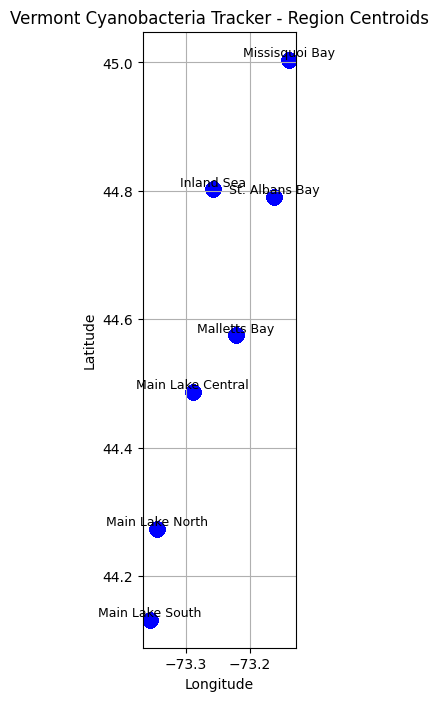

In [57]:
# Plot regions on a scatterplot

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    vct_region_df["longitude"], 
    vct_region_df["latitude"], 
    s=100,       
    alpha=0.7,
    color="blue"
)

# Label each region
for _, row in vct_region_df.drop_duplicates("region").iterrows():
    ax.text(
        row["longitude"], 
        row["latitude"], 
        row["region"], 
        fontsize=9, 
        ha="center",
        va="bottom"
    )

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Vermont Cyanobacteria Tracker - Region Centroids")
ax.grid(True)
ax.set_aspect("equal", adjustable="box")

plt.show()


### Remove bad values from features

In [58]:
# Set water temperatures over 100 to NaN

print(len(vct_region_df["water_temp"].unique()))

vct_feature_clean_df = vct_region_df.copy()

vct_feature_clean_df["water_temp"] = (
    pd.to_numeric(vct_feature_clean_df["water_temp"], errors="coerce")
)

vct_feature_clean_df.loc[
    vct_feature_clean_df["water_temp"] > 100,
    "water_temp"
] = np.nan

print(len(vct_feature_clean_df["water_temp"].unique()))


455
414


### Reorder & rename columns for output

In [79]:
# Reorder and rename columns

col_order = [
    "report_date",
    "waterbody",
    "region",
    "site",
    "station",
    "latitude",
    "longitude",
    "cyanotaxa",
    "water_temp",
    "water_surface",
    "anabaena",
    "aphanizomenon",
    "microcystin",
    "oscillatoria",
    "target_bloom_intensity",
    "target_bloom",
]

# Rename columns
col_map = {
    "water_temp": "feature_water_temp",
    "water_surface": "feature_water_surface",
    "anabaena": "feature_anabaena",
    "aphanizomenon": "feature_aphanizomenon",
    "microcystin": "feature_microcystin",
    "oscillatoria": "feature_oscillatoria",
}

vct_clean_df = (
    vct_feature_clean_df[col_order]
    .copy()
    .rename(columns=col_map)
)

### Calculate density of features

In [61]:
vct_clean_df.columns

Index(['report_date', 'waterbody', 'region', 'site', 'station', 'latitude',
       'longitude', 'cyanotaxa', 'feature_water_temp', 'feature_water_surface',
       'feature_anabaena', 'feature_aphanizomenon', 'feature_microcystin',
       'feature_oscillatoria', 'target_bloom_intensity', 'target_bloom'],
      dtype='object')

In [62]:
# Presence of blooms and cyanotaxa

cyano_features = ["feature_anabaena", "feature_aphanizomenon", "feature_microcystin", "feature_oscillatoria"]

# Percent of cyano values
for feature in cyano_features:
    percent_1 = (vct_clean_df[feature] == 1).mean() * 100
    print(f"{feature}: {percent_1:.2f}%")

# Percent of days with blooms
percent_bloom = (vct_clean_df["target_bloom"] == 1).mean() * 100
print(f"Bloom: {percent_bloom:.2f}%")

feature_anabaena: 3.87%
feature_aphanizomenon: 3.48%
feature_microcystin: 2.14%
feature_oscillatoria: 0.40%
Bloom: 13.37%


In [63]:
# Coverage for water features

# Get year from the date
vct_clean_df["report_date"] = pd.to_datetime(vct_clean_df["report_date"])
vct_clean_df["year"] = vct_clean_df["report_date"].dt.year

# Columns that must all be non-NaN
# required_cols = ["feature_water_temp"] + cyano_features + ["target_bloom"]
features = ["feature_water_temp", "feature_water_surface"]

for feature in features:

    yearly_percents = []
    total_valid_days = 0
    total_possible_days = 0

    for year, df_year in vct_clean_df.groupby("year"):

        min_date = df_year["report_date"].min()
        max_date = df_year["report_date"].max()

        full_range = pd.date_range(start=min_date, end=max_date, freq="D")

        # Days where this feature is non-NaN
        valid_days = (
            df_year
            .dropna(subset=[feature])
            ["report_date"]
            .dt.normalize()
            .unique()
        )

        percent_valid = len(valid_days) / len(full_range) * 100
        yearly_percents.append(percent_valid)

        total_valid_days += len(valid_days)
        total_possible_days += len(full_range)

    # Straight average across years
    avg_percent = np.mean(yearly_percents)

    # Weighted overall percent
    weighted_percent = (total_valid_days / total_possible_days) * 100

    print(f"\n{feature}")
    # print(f"Average yearly percent: {avg_percent:.2f}%")
    print(f"Weighted overall percent: {weighted_percent:.2f}%")



feature_water_temp
Weighted overall percent: 79.25%

feature_water_surface
Weighted overall percent: 89.73%


C:\Users\hefla\AppData\Local\Temp\ipykernel_26328\3201169312.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vct_clean_df["report_date"] = pd.to_datetime(vct_clean_df["report_date"])
C:\Users\hefla\AppData\Local\Temp\ipykernel_26328\3201169312.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vct_clean_df["year"] = vct_clean_df["report_date"].dt.year


### Average daily values together per region

In [117]:
# Define a safe mode function so I can calculate mode across fields that might be NA
 
def safe_mode(x):
    m = x.mode()
    return m.iloc[0] if not m.empty else pd.NA

In [140]:
# Group and aggregate by day

vct_grouped_df = (
    vct_clean_df
        .groupby(["region", "report_date"], as_index=False)
        .agg({
            "feature_water_surface": safe_mode,
            "feature_water_surface": safe_mode,
            "feature_water_temp": "mean",
            "latitude": "mean",
            "longitude": "mean",
            "feature_water_surface": safe_mode,
            "feature_anabaena": "max",
            "feature_aphanizomenon": "max",
            "feature_microcystin": "max",
            "feature_oscillatoria": "max",
            "target_bloom_intensity": "max",
            "target_bloom": "max",
        })
)

### Trailing windows for feature data

In [142]:
# Compute trailing days for features

# Right now I'm only grouping on report date and region - we should talk about if we want to add in other criteria to group by
# vct_trailing_df = vct_grouped_df.sort_values(["site", "report_date", "region", "station"]).copy()
vct_trailing_df = vct_grouped_df.copy()
vct_trailing_df["report_date"] = pd.to_datetime(vct_trailing_df["report_date"])
vct_trailing_df = vct_trailing_df.sort_values(["region", "report_date"])
# vct_trailing_df = vct_trailing_df.set_index("report_date")

trailing_days = 7
window_str = f"{trailing_days}D"

trailing_cont_features = ["feature_water_temp"]
trailing_cat_features = ["feature_water_surface", "feature_anabaena", "feature_aphanizomenon", "feature_microcystin", "feature_oscillatoria"]

for col in trailing_cont_features:
    new_col = f"{col}_trailing"
    vct_trailing_df[new_col] = (
        vct_trailing_df
            .groupby("region", group_keys=False)
            .apply(lambda g:
                g.sort_values("report_date")
                 .assign(_val=pd.to_numeric(g[col], errors="coerce"))
                 .rolling(window_str, on="report_date", min_periods=1)["_val"]
                 .mean()
                 .shift(1), include_groups=False
            )
    )

def trailing_mode(group, col, window):
    group = group.sort_values("report_date").copy()
    
    result = []

    for i in range(len(group)):
        current_date = group.iloc[i]["report_date"]
        start_date = current_date - pd.Timedelta(days=window)

        window_data = group[
            (group["report_date"] >= start_date) &
            (group["report_date"] < current_date)
        ][col].dropna()

        if len(window_data) > 0:
            result.append(window_data.mode().iloc[0])
        else:
            result.append(np.nan)

    return pd.Series(result, index=group.index)

for col in trailing_cat_features:
    new_col = f"{col}_trailing"

    vct_trailing_df[new_col] = (
        vct_trailing_df
            .groupby("region", group_keys=False)
            .apply(lambda g: trailing_mode(g, col, trailing_days), include_groups=False)
    )

vct_trailing_df.head()

,region,report_date,feature_water_surface,feature_water_temp,latitude,longitude,feature_anabaena,feature_aphanizomenon,feature_microcystin,feature_oscillatoria,target_bloom_intensity,target_bloom,feature_water_temp_trailing,feature_water_surface_trailing,feature_anabaena_trailing,feature_aphanizomenon_trailing,feature_microcystin_trailing,feature_oscillatoria_trailing
10,Inland Sea,2014-06-15,Calm,NaN,44.802657,-73.256856,0,0,0,0,1a,0,NaN,NaN,NaN,NaN,NaN,NaN
14,Inland Sea,2014-06-16,Calm,71.900000,44.802657,-73.256856,0,0,0,0,1d,0,NaN,Calm,0.0,0.0,0.0,0.0
18,Inland Sea,2014-06-17,Calm,64.000000,44.802657,-73.256856,0,0,0,0,1a,0,71.900000,Calm,0.0,0.0,0.0,0.0
25,Inland Sea,2014-06-19,Calm,70.000000,44.802657,-73.256856,0,0,0,0,1b,0,67.950000,Calm,0.0,0.0,0.0,0.0
44,Inland Sea,2014-06-23,Calm,71.966667,44.802657,-73.256856,0,0,0,0,1c,0,68.633333,Calm,0.0,0.0,0.0,0.0


### Output file

In [143]:
output_df = vct_trailing_df.copy()
output_df.head()

,region,report_date,feature_water_surface,feature_water_temp,latitude,longitude,feature_anabaena,feature_aphanizomenon,feature_microcystin,feature_oscillatoria,target_bloom_intensity,target_bloom,feature_water_temp_trailing,feature_water_surface_trailing,feature_anabaena_trailing,feature_aphanizomenon_trailing,feature_microcystin_trailing,feature_oscillatoria_trailing
10,Inland Sea,2014-06-15,Calm,NaN,44.802657,-73.256856,0,0,0,0,1a,0,NaN,NaN,NaN,NaN,NaN,NaN
14,Inland Sea,2014-06-16,Calm,71.900000,44.802657,-73.256856,0,0,0,0,1d,0,NaN,Calm,0.0,0.0,0.0,0.0
18,Inland Sea,2014-06-17,Calm,64.000000,44.802657,-73.256856,0,0,0,0,1a,0,71.900000,Calm,0.0,0.0,0.0,0.0
25,Inland Sea,2014-06-19,Calm,70.000000,44.802657,-73.256856,0,0,0,0,1b,0,67.950000,Calm,0.0,0.0,0.0,0.0
44,Inland Sea,2014-06-23,Calm,71.966667,44.802657,-73.256856,0,0,0,0,1c,0,68.633333,Calm,0.0,0.0,0.0,0.0


### Merge into one unified csv

In [144]:
# Output the unified csv file

output_df.to_csv(output_path, index=False)